# Pandas Practice Tasks
Work through each task in order. Try to solve it yourself before looking anything up!

In [ ]:
import pandas as pd
import numpy as np
import matplotlib

---
## Level 1 — Basics

### Task 1: Create a DataFrame
Create a DataFrame with 5 rows representing students.
Columns: `name`, `age`, `grade` (use grades A, B, or C).
Print the DataFrame.

In [2]:
# Your code here
data = {
    'name':  ["Alice","Bob", "Charles","Doug","Emma"],   # 5 names
    'age':   [12,30,14,15,60],   # 5 ages
    'grade': ["A","A","B","B","C"],   # 5 grades (A, B, or C)
}

students = pd.DataFrame(data)
students

,name,age,grade
0,Alice,12,A
1,Bob,30,A
2,Charles,14,B
3,Doug,15,B
4,Emma,60,C


### Task 2: Inspect a Dataset
Run the cells below to load a built-in dataset, then use `.head()`, `.info()`, `.describe()`, and `.shape` to explore it.
**Question to answer:** How many rows and columns are there? What data types are used?

In [4]:
# Run this to load a sample dataset
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv'
iris = pd.read_csv(url)

# Now explore it — try .head(), .info(), .describe(), .shape below
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
iris.shape

(150, 5)

In [6]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Task 3: Select & Filter
Using your `students` DataFrame from Task 1:
1. Select only students with grade `"A"`
2. From all students, select just the `name` column

In [13]:
# 1. Filter rows where grade == 'A'
top_students = students[students['grade'] == 'A']
print(top_students)

# 2. Select just the 'name' column
names = top_students['name']
print(names)

    name  age grade
0  Alice   12     A
1    Bob   30     A
0    Alice
1      Bob
Name: name, dtype: object


---
## Level 2 — Transformations

### Task 4: Add a Column
Add a column `passed` to your `students` DataFrame.
It should be `True` if grade is `"A"` or `"B"`, and `False` if grade is `"C"`.

In [ ]:
# Add a 'passed' column
students['passed'] = True
students.loc[students['grade']=='C','passed'] = False
students
#students.iloc[0] # print the first row as series
#students.iloc[[0]] # print the first row as a DataFrame
# better solution:
#students = students.drop(columns=['passed'])
#students['passed']=students['grade'].isin(['A','B'])
#students

,name,age,grade,passed
0,Alice,12,A,True


### Task 5: Handle Missing Data
A DataFrame with `NaN` values has been created for you.
1. Find which cells are null using `.isnull()`
2. Drop rows with any null values using `.dropna()`
3. Fill null values with `0` using `.fillna()`

In [24]:
# Starter data — don't change this
messy = pd.DataFrame({
    'a': [1, 2, np.nan, 4],
    'b': [np.nan, 2, 3, 4],
    'c': [1, 2, 3, np.nan],
})

# 1. Show which values are null
messy.isnull()

# 2. Drop rows with any null

messy.dropna()
# 3. Fill nulls with 0
messy.fillna(0)


,a,b,c
0,1.0,0.0,1.0
1,2.0,2.0,2.0
2,0.0,3.0,3.0
3,4.0,4.0,0.0


### Task 6: Sort & Rank
A products DataFrame has been created for you.
1. Sort by `price` descending
2. Add a `rank` column (1 = most expensive) using `.rank()`

In [30]:
# Starter data — don't change this
products = pd.DataFrame({
    'name':  ['Apple', 'Banana', 'Cherry', 'Date', 'Elderberry'],
    'price': [1.20, 0.30, 3.50, 5.00, 2.75],
})

# 1. Sort by price descending
products.sort_values('price',ascending= False)

# 2. Add a rank column (1 = most expensive)
products['rank'] = products['price'].rank(ascending=False)
products

,name,price,rank
0,Apple,1.20,4.0
1,Banana,0.30,5.0
2,Cherry,3.50,2.0
3,Date,5.00,1.0
4,Elderberry,2.75,3.0


---
## Level 3 — Aggregation

### Task 7: GroupBy
Using the sales DataFrame below, find the **total revenue per region** using `.groupby()`.

In [35]:
# Starter data — don't change this
sales = pd.DataFrame({
    'region':      ['North', 'South', 'North', 'East', 'South', 'East', 'North'],
    'salesperson': ['Alice', 'Bob', 'Carol', 'Dave', 'Alice', 'Bob', 'Dave'],
    'revenue':     [200, 150, 300, 250, 180, 220, 310],
})

# Total revenue per region
revenue_by_region = sales.groupby('region')['revenue'].sum()
revenue_by_region

region
East     470
North    810
South    330
Name: revenue, dtype: int64

### Task 8: Pivot Table
Using the same `sales` DataFrame, create a pivot table showing the **average revenue** for each combination of `region` and `salesperson`.

In [39]:
# Create a pivot table
pivot = pd.pivot_table(
    sales,
    values='revenue',
    index='salesperson',
    columns='region',
    aggfunc='mean'
)
pivot

region,East,North,South
salesperson,,,
Alice,NaN,200.0,180.0
Bob,220.0,NaN,150.0
Carol,NaN,300.0,NaN
Dave,250.0,310.0,NaN


### Task 9: Merge DataFrames
Two DataFrames are provided. Merge them on `employee_id` so each row has name and salary.

In [40]:
# Starter data — don't change this
employees = pd.DataFrame({
    'employee_id': [1, 2, 3, 4],
    'name':        ['Alice', 'Bob', 'Carol', 'Dave'],
})

salaries = pd.DataFrame({
    'employee_id': [1, 2, 3, 5],   # note: id 4 is missing, id 5 is extra
    'salary':      [70000, 85000, 60000, 90000],
})

# Merge on employee_id (try 'inner', 'left', 'outer' and see what changes)
merged = pd.merge(employees, salaries, on='employee_id', how='inner')
merged

,employee_id,name,salary
0,1,Alice,70000
1,2,Bob,85000
2,3,Carol,60000


---
## Level 4 — Real-world

### Task 10: Time Series
1. Create a DataFrame with a daily date range for all of 2024 and a random `value` column
2. Set the date as the index
3. Resample to **weekly averages** and plot the result

Matplotlib is building the font cache; this may take a moment.


<Axes: title={'center': 'Weekly Average'}, xlabel='date'>

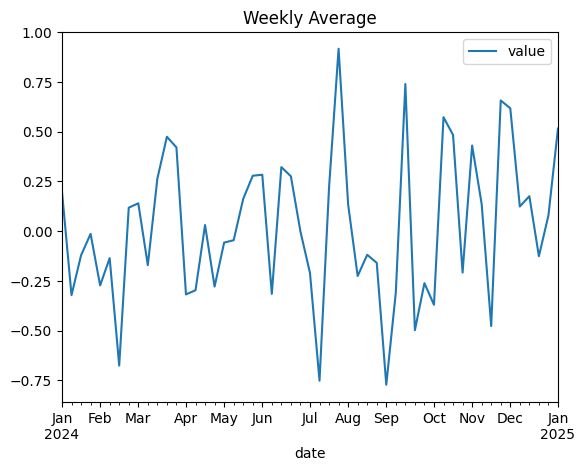

In [44]:
# 1. Create date range for 2024
dates = pd.date_range(start='2024-01-01', end='2024-12-31', freq='D')

ts = pd.DataFrame({
    'date':  dates,
    'value': np.random.randn(len(dates)),
})

# 2. Set date as index
ts = ts.set_index('date')

# 3. Resample to weekly averages
weekly = ts.resample('W').mean()

# Plot it
weekly.plot(title='Weekly Average')

In [45]:
weekly

,value
date,
2024-01-07,0.198524
2024-01-14,-0.322005
2024-01-21,-0.122008
2024-01-28,-0.014173
2024-02-04,-0.273253
2024-02-11,-0.135979
2024-02-18,-0.675855
2024-02-25,0.117260
2024-03-03,0.139550
